# ***Problem Statement***
AeroFit, a leading fitness equipment brand, offers three treadmill models (KP281, KP481, and KP781) with varying prices and features. The market research team lacks a clear understanding of which customer segments prefer which product. To improve customer recommendations and marketing efficiency, AeroFit needs to identify the distinct characteristics—such as age, gender, income, and fitness level—of the target audience for each treadmill.

# ***Objective***


*   Create detailed customer profiles for each treadmill model.
*   Identify significant differences in customer characteristics across the product line.



*   Determine the marginal and conditional probabilities of purchase based on customer attributes.
*   Provide actionable business recommendations for targeted marketing and product positioning.

# ***Insights***



1.   **The "Premium" Wall:** There is a very sharp divide when it comes to the KP781 (the expensive model). Data shows that almost no one with "Low" or "Medium" income buys it. It’s almost exclusively purchased by people in the "High Income" bracket.
2.   **The Gender Gap in Performance:** While men and women both buy the entry-level models, the KP781 is heavily dominated by male customers (over 80%). Women who do buy it tend to be highly fit, but they are a very small percentage of the total sales for that model.


1.   **Fitness as a Predictor:** A customer’s fitness score is the best way to predict which machine they’ll buy. People who rate themselves a "5" for fitness almost always go for the KP781, while those who rate themselves a "3" or lower stay with the KP281 or KP481.
2.  **The Overlapping Middle:** The KP281 and KP481 customers look almost exactly the same on paper. They have similar ages, incomes, and fitness levels. This suggests that the KP481 (the mid-level model) doesn't have its own unique "fan base" yet; it’s just a slightly more expensive version of the starter model.


1.   **Usage Habits:** There is a massive jump in "Miles" and "Usage" for KP781 owners. These aren't just casual walkers; they are running 150+ miles. On the other hand, the KP281 and KP481 users have very similar, moderate usage patterns.






# ***Recommendation***



1.   **Target High-Income Professionals for the KP781:** Since income is the biggest factor for the expensive model, the marketing team should focus digital ads on high-income zip codes or professional networking sites rather than general fitness groups.

1.   **Create a "Pro-Female" Campaign for the KP781:** Since female buyers are currently avoiding the top-tier model, AeroFit should create marketing content specifically showing high-performance female athletes using the KP781. This could tap into a market that is currently being ignored.

1.   **Give the KP481 a "Unique Identity":** To stop the KP481 from being "stuck in the middle," the business should market it for a specific niche—perhaps as the "Best for Long Distance Walkers" or "Best for Seniors"—to distinguish it from the entry-level KP281.
2.   **Use the "Fitness Quiz" Strategy:** Since self-rated fitness is such a strong predictor, the website should have a 3-question "Fitness Quiz" for new visitors. If a user selects "High Fitness" and "Daily Use," the site should automatically push the KP781, as that's exactly what that profile buys.


2.  **Focus on Partnered Couples:** Data shows that people in relationships (Partnered) buy more treadmills than single people. You could offer a "His and Hers" bundle or a discount for a second machine to encourage these "Partnered" households to upgrade their home gym.



In [ ]:
# import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Importing the Aerofit data into Colab
url = "https://docs.google.com/spreadsheets/d/1SeP24j0aKLDJvjT7Ejbn1XQhGuWUNR2iWGsoNuKydpY/export?format=csv"
df = pd.read_csv(url)

# ***Data Overview***

In [ ]:
# Summary of the DataFrame, including the index, data types, and non-null values. Using info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


In [ ]:
# Checking number of rows and columns
df.shape

(180, 9)

In [ ]:
# Generate summary statistics for all columns (numeric + categorical + object) in a DataFrame
df.describe(include= 'all')

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
count,180,180.000000,180,180.000000,180,180.000000,180.000000,180.000000,180.000000
unique,3,NaN,2,NaN,2,NaN,NaN,NaN,NaN
top,KP281,NaN,Male,NaN,Partnered,NaN,NaN,NaN,NaN
freq,80,NaN,104,NaN,107,NaN,NaN,NaN,NaN
mean,NaN,28.788889,NaN,15.572222,NaN,3.455556,3.311111,53719.577778,103.194444
std,NaN,6.943498,NaN,1.617055,NaN,1.084797,0.958869,16506.684226,51.863605
min,NaN,18.000000,NaN,12.000000,NaN,2.000000,1.000000,29562.000000,21.000000
25%,NaN,24.000000,NaN,14.000000,NaN,3.000000,3.000000,44058.750000,66.000000
50%,NaN,26.000000,NaN,16.000000,NaN,3.000000,3.000000,50596.500000,94.000000
75%,NaN,33.000000,NaN,16.000000,NaN,4.000000,4.000000,58668.000000,114.750000


In [ ]:
# Convert Categorical Variables
df['Product'] = df['Product'].astype('category')
df['Gender'] = df['Gender'].astype('category')
df['MaritalStatus'] = df['MaritalStatus'].astype('category')

In [ ]:
# Check Missing Values
df.isnull().sum()

,0
Product,0
Age,0
Gender,0
Education,0
MaritalStatus,0
Usage,0
Fitness,0
Income,0
Miles,0


# ***Univariate Analysis***

In [ ]:
# Product Distribtion
df['Product'].value_counts().reset_index(name = "Product Count")


,Product,Product Count
0,KP281,80
1,KP481,60
2,KP781,40


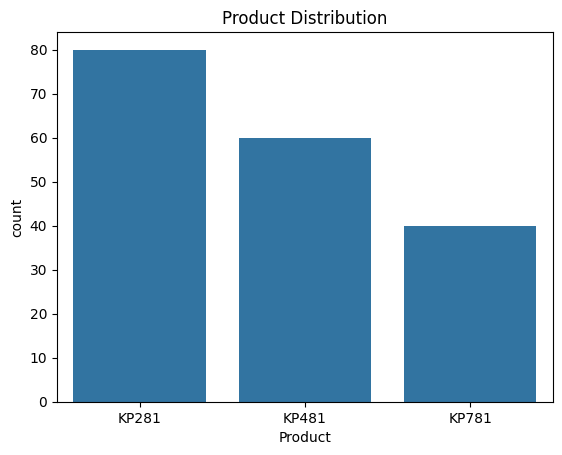

In [ ]:
sns.countplot(x='Product', data=df)
plt.title("Product Distribution")
plt.show()

In [ ]:
# Gender Distribution
df['Gender'].value_counts().reset_index(name = "Users")

,Gender,Users
0,Male,104
1,Female,76


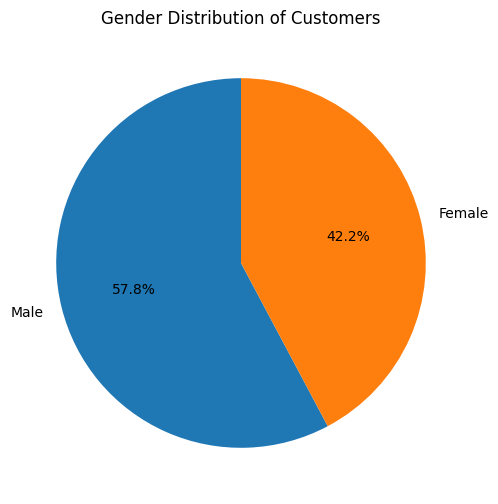

In [ ]:
gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(gender_counts,
        labels=gender_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Gender Distribution of Customers")
plt.show()

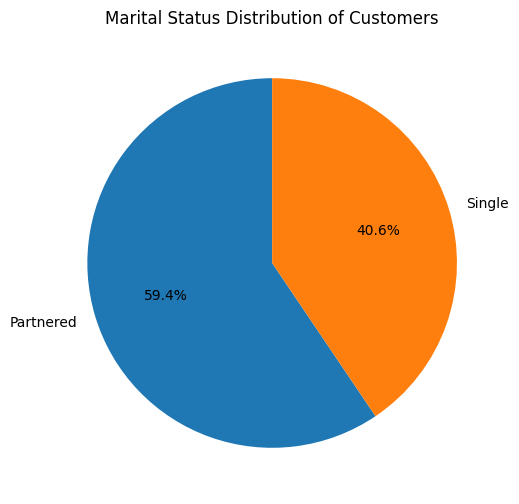

In [ ]:
marital_counts = df['MaritalStatus'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(marital_counts,
        labels=marital_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Marital Status Distribution of Customers")
plt.show()

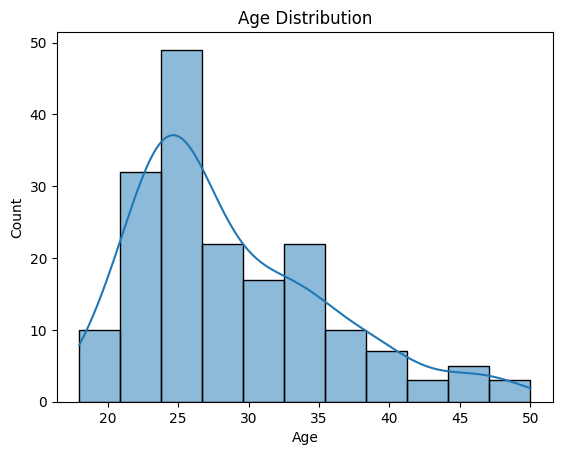

In [ ]:
# Age distribution
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

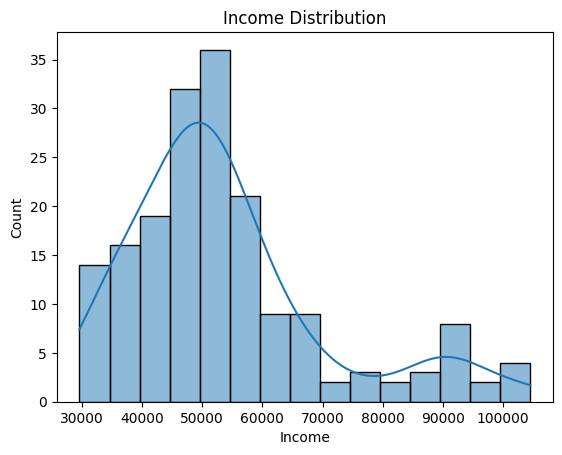

In [ ]:
# Income Distribution
sns.histplot(df['Income'], kde=True)
plt.title("Income Distribution")
plt.show()

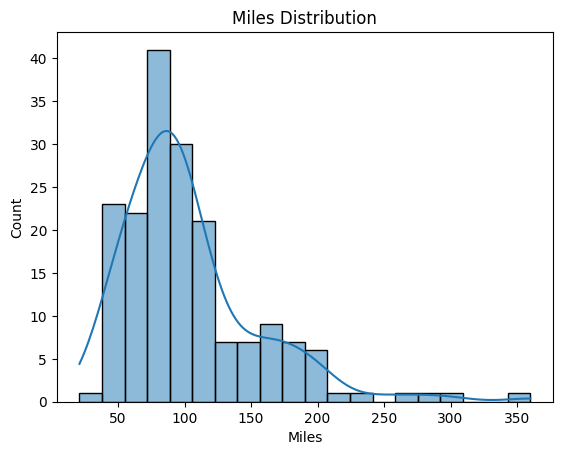

In [ ]:
# Miles Distribution
sns.histplot(df['Miles'], kde=True)
plt.title("Miles Distribution")
plt.show()

# ***Outliers Detection***

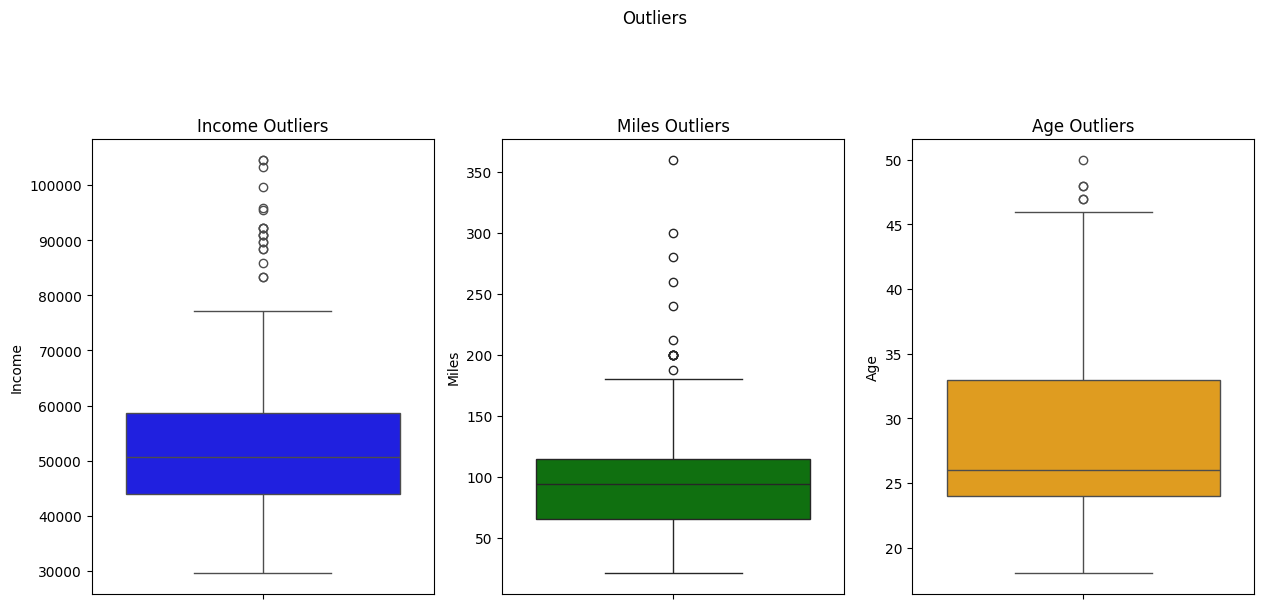

In [ ]:
fig=plt.figure(figsize=(15,13))

plt.subplot(2,3,1)
sns.boxplot(df['Income'],color = 'blue')
plt.title("Income Outliers")

plt.subplot(2,3,2)
sns.boxplot(df['Miles'],color = 'green')
plt.title("Miles Outliers")

plt.subplot(2,3,3)
sns.boxplot(df['Age'],color = 'orange')
plt.title("Age Outliers")

fig.suptitle('Outliers')
plt.show()


# ***Bivariate Analysis***

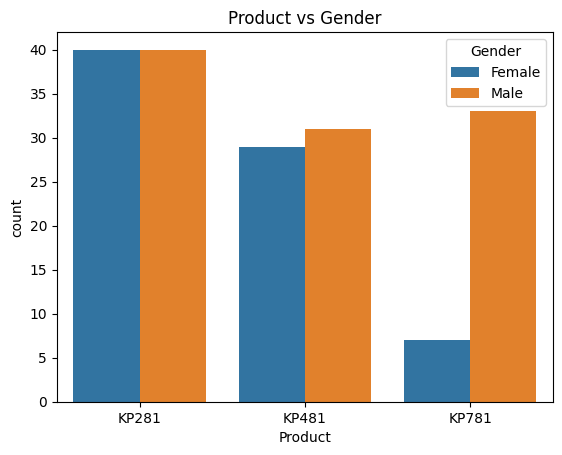

In [ ]:
# Product vs Gender
sns.countplot(x='Product', hue='Gender', data=df)
plt.title("Product vs Gender")
plt.show()

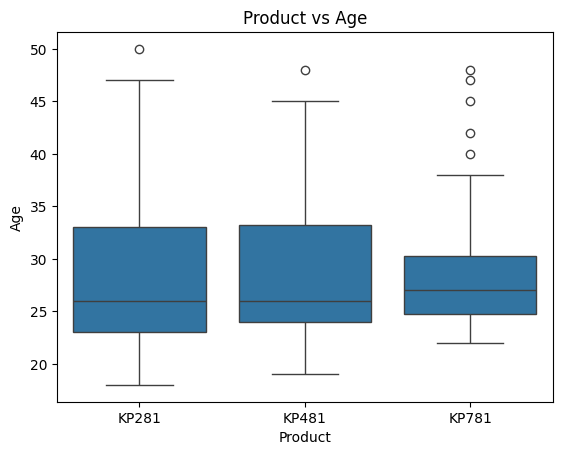

In [ ]:
# Product vs Age
sns.boxplot(x='Product', y='Age', data=df)
plt.title("Product vs Age")
plt.show()

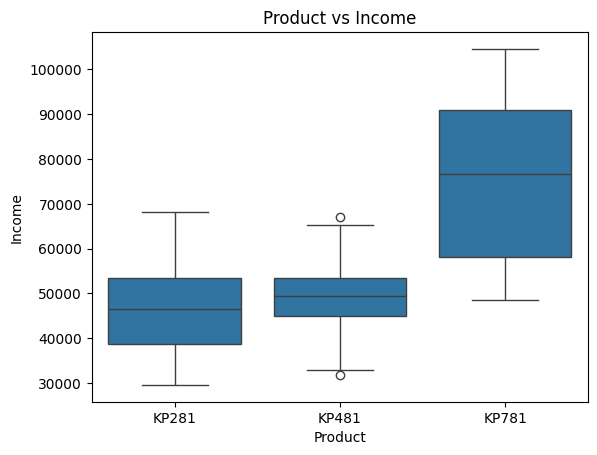

In [ ]:
# Product vs Income
sns.boxplot(x='Product', y='Income', data=df)
plt.title("Product vs Income")
plt.show()

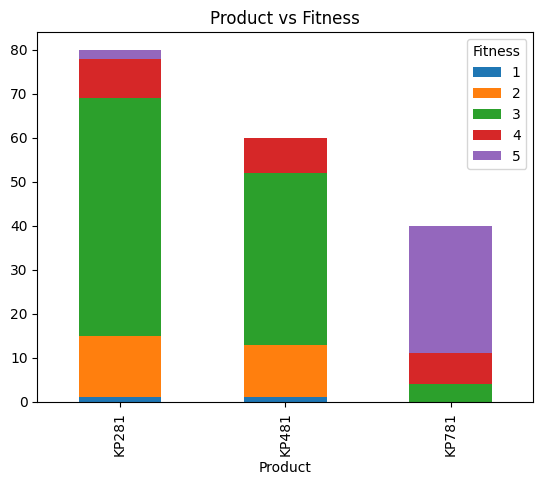

In [ ]:
# Product vs Fitness
df_stacked_plot = pd.crosstab(index = df['Product'],columns = df['Fitness'])
df_stacked_plot.plot(kind = 'bar',stacked = True)
plt.title("Product vs Fitness")
plt.show()

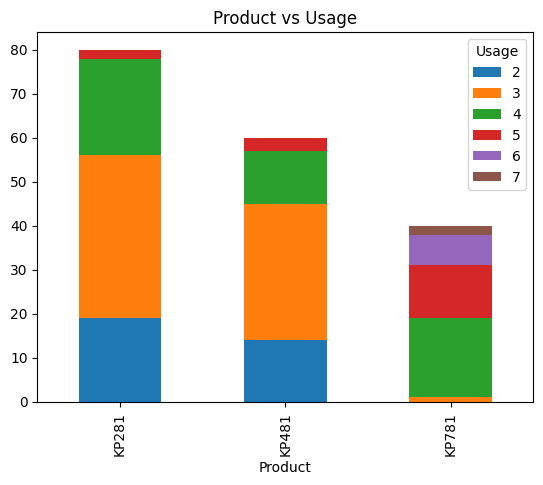

In [ ]:
# Product vs Usage
df_stacked_plot = pd.crosstab(index = df['Product'],columns = df['Usage'])
df_stacked_plot.plot(kind = 'bar',stacked = True)
plt.title("Product vs Usage")
plt.show()

In [ ]:
bins = [18,25,35,45,60]
labels = ['Young Adults','Working Professionals','Mid Age','Senior']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

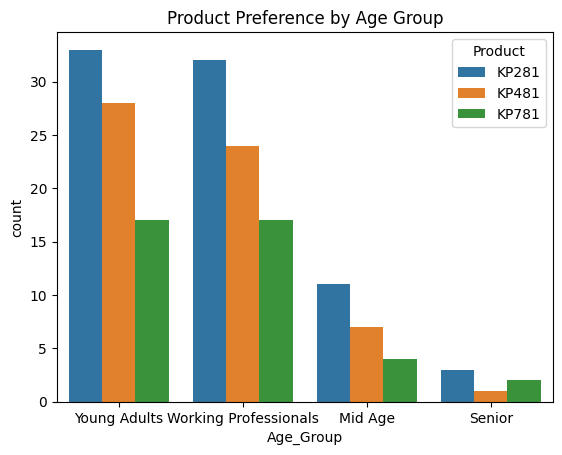

In [ ]:
# Product Preference by Age Group
sns.countplot(x='Age_Group', hue='Product', data=df)
plt.title("Product Preference by Age Group")
plt.show()

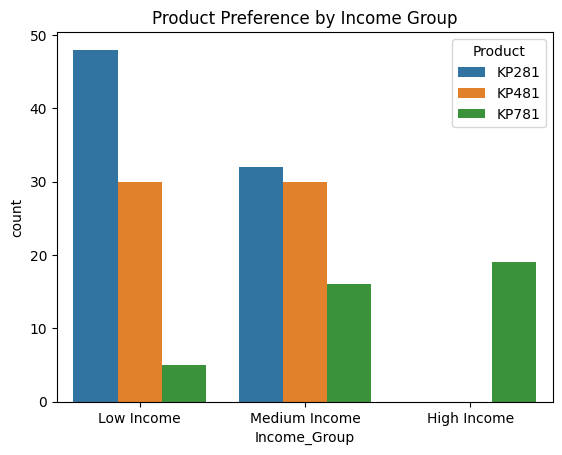

In [ ]:
# Income Segmentation
bins = [20000,50000,80000,120000]
labels = ['Low Income','Medium Income','High Income']
df['Income_Group'] = pd.cut(df['Income'], bins=bins, labels=labels)

sns.countplot(x='Income_Group', hue='Product', data=df)
plt.title("Product Preference by Income Group")
plt.show()

# **Multivariate Analysis**

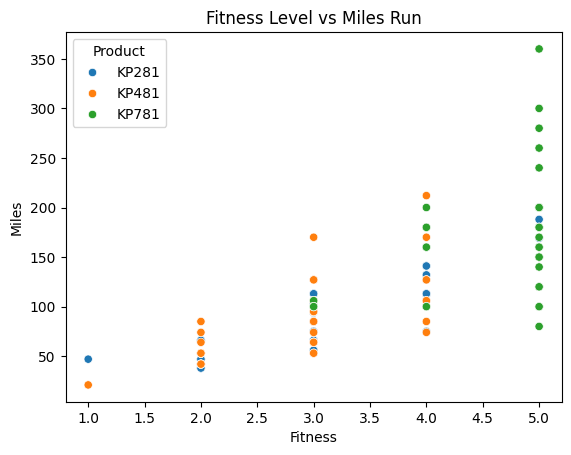

In [ ]:
# Fitness Level vs Miles Run
sns.scatterplot(x='Fitness', y='Miles',hue='Product', data=df)
plt.title("Fitness Level vs Miles Run")
plt.show()

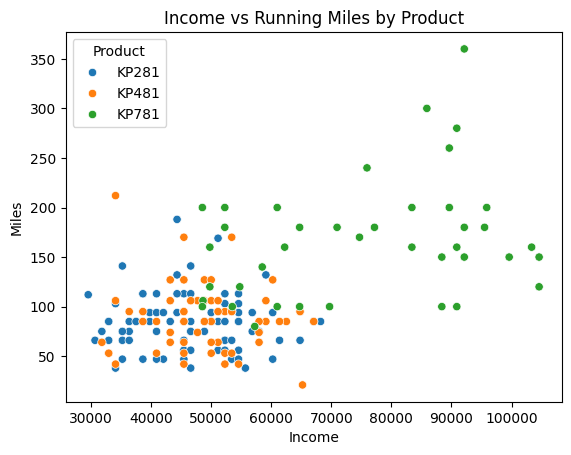

In [ ]:
sns.scatterplot(x='Income', y='Miles', hue='Product', data=df)
plt.title("Income vs Running Miles by Product")
plt.show()

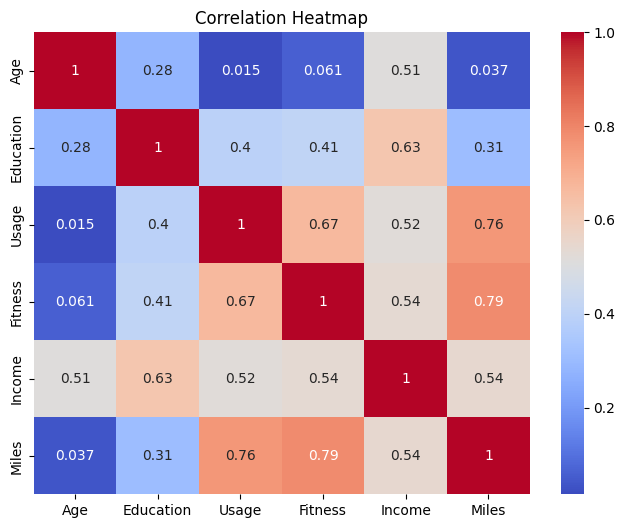

In [ ]:
plt.figure(figsize=(8,6))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True,  cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# ***Marginal Probability***

In [ ]:
product = pd.crosstab(df['Product'], columns='Probability', normalize=True).reset_index()
product['Probability'] = round(product['Probability'] * 100, 2)
product

col_0,Product,Probability
0,KP281,44.44
1,KP481,33.33
2,KP781,22.22


# ***Conditional Probability***

In [ ]:
# Probability of Gender Buying Each Product
data = pd.crosstab(df['Product'], df['Gender'], normalize='columns').reset_index()
data['Female'] = round(data['Female'] * 100, 2)
data['Male'] = round(data['Male'] * 100, 2)
data.columns.name = None
data

,Product,Female,Male
0,KP281,52.63,38.46
1,KP481,38.16,29.81
2,KP781,9.21,31.73


In [ ]:
# Probability Based on Marital Status
data = pd.crosstab(df['Product'], df['MaritalStatus'], normalize='columns').reset_index()
data['Partnered'] = round(data['Partnered'] * 100, 2)
data['Single'] = round(data['Single'] * 100, 2)
data.columns.name = None
data

,Product,Partnered,Single
0,KP281,44.86,43.84
1,KP481,33.64,32.88
2,KP781,21.50,23.29


In [ ]:
data = pd.crosstab(df['Fitness'], df['Product'], normalize='columns').reset_index()
data['KP281'] = round(data['KP281'] * 100, 2)
data['KP481'] = round(data['KP481'] * 100, 2)
data['KP781'] = round(data['KP781'] * 100, 2)
data.columns.name = None
data

,Fitness,KP281,KP481,KP781
0,1,1.25,1.67,0.0
1,2,17.50,20.00,0.0
2,3,67.50,65.00,10.0
3,4,11.25,13.33,17.5
4,5,2.50,0.00,72.5
